# Feedback Simulator
Don't forget to
`sshfs -o allow_other,defer_permissions alexandresayal@192.168.0.68:/ /Users/alexandresayal/sftp -ovolname=sftp`

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nilearn.maskers import NiftiSpheresMasker

In [2]:
# Settings
data_dir = '/Users/alexandresayal/sftp/DATAPOOL/VPMB/BIDS-VPMB-SPE'
fmriprep_dir = '/Users/alexandresayal/sftp/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/fmriprep23/fmriprep'
nilearn_dir = '/Users/alexandresayal/sftp/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/nilearn_glm'
output_dir = '/Users/alexandresayal/sftp/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/feedbackSimulator'
subject_list = [x for x in os.listdir(data_dir) if 'sub-' in x]
subject_list.sort()

In [7]:
subject_label = 'sub-02'
tr = 0.5 # in seconds
hrf_delay = 4 # in seconds
run_type = 'UA' # 'AA' (ambiguous) or 'UA' (unambiguous)

# get paths
task_label = f'task-{run_type}_acq-{round(tr*1000):04}_run-1'
active_cond_name = 'Ambiguous' if run_type=='AA' else 'Unambiguous'
fmri_img = os.path.join(fmriprep_dir, subject_label, 'func', f'{subject_label}_{task_label}_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz')
#mask_img = os.path.join(nilearn_dir,'group','mask_hMT.nii.gz')
confounds_file = os.path.join(fmriprep_dir, subject_label, 'func', f'{subject_label}_{task_label}_desc-confounds_timeseries.tsv')
events_file = os.path.join(data_dir, subject_label, 'func', f'{subject_label}_{task_label}_events.tsv')

In [4]:
# load confounds (all columns that start with 'cosine', 'csf', 'white_matter')
# and remove NaNs
confounds = pd.read_csv(confounds_file, sep='\t')
confounds = confounds.filter(regex='^(csf|white_matter|trans|rot).*')
confounds.fillna(0, inplace=True)

confounds.columns

Index(['csf', 'csf_derivative1', 'csf_power2', 'csf_derivative1_power2',
       'white_matter', 'white_matter_derivative1',
       'white_matter_derivative1_power2', 'white_matter_power2', 'csf_wm',
       'trans_x', 'trans_x_derivative1', 'trans_x_power2',
       'trans_x_derivative1_power2', 'trans_y', 'trans_y_derivative1',
       'trans_y_derivative1_power2', 'trans_y_power2', 'trans_z',
       'trans_z_derivative1', 'trans_z_power2', 'trans_z_derivative1_power2',
       'rot_x', 'rot_x_derivative1', 'rot_x_power2',
       'rot_x_derivative1_power2', 'rot_y', 'rot_y_derivative1',
       'rot_y_power2', 'rot_y_derivative1_power2', 'rot_z',
       'rot_z_derivative1', 'rot_z_derivative1_power2', 'rot_z_power2'],
      dtype='object')

In [5]:
# Load events file
events = pd.read_csv(events_file, sep='\t')
events

,onset,duration,trial_type
0,0,15,Discard
1,15,30,Static
2,45,120,Unambiguous
3,165,15,MAE
4,180,30,Static
5,210,120,Unambiguous
6,330,15,MAE
7,345,30,Static
8,375,15,Discard


In [6]:
# Fetch the points of 'Static' events (to normalize the time_series)
static_events = events[events['trial_type']=='Static']

# Get the time points of the static events - these start at the onset and last for duration
static_events_onsets = static_events['onset'].values
static_events_durations = static_events['duration'].values

# create vector with all the time points of the static events
static_events_indexes = np.array([])
for i in range(len(static_events_onsets)):
    static_events_indexes = np.append(static_events_indexes, np.arange(static_events_onsets[i]/tr, static_events_onsets[i]/tr+static_events_durations[i]/tr))

static_events_indexes = ( static_events_indexes - 1 + (hrf_delay/tr) ).astype(int)
static_events_indexes


array([ 37,  38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,
        50,  51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,
        63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,
        76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,
        89,  90,  91,  92,  93,  94,  95,  96, 367, 368, 369, 370, 371,
       372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384,
       385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397,
       398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410,
       411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423,
       424, 425, 426, 697, 698, 699, 700, 701, 702, 703, 704, 705, 706,
       707, 708, 709, 710, 711, 712, 713, 714, 715, 716, 717, 718, 719,
       720, 721, 722, 723, 724, 725, 726, 727, 728, 729, 730, 731, 732,
       733, 734, 735, 736, 737, 738, 739, 740, 741, 742, 743, 744, 745,
       746, 747, 748, 749, 750, 751, 752, 753, 754, 755, 756])

In [8]:
# get the time points of the ambiguous/unambiguous blocks
active_events = events[events['trial_type']==active_cond_name]
active_events_onsets = active_events['onset'].values
active_events_durations = active_events['duration'].values

# create matrix with all the time points of the ambiguous blocks, one per column
active_events_indexes = np.array([])

# convert times to indexes and add hemodynamic delay
for i in range(len(active_events_onsets)):
    active_events_indexes = np.append(active_events_indexes,
                                         np.arange(active_events_onsets[i]/tr, active_events_onsets[i]/tr+active_events_durations[i]/tr))

active_events_indexes = ( active_events_indexes - 1 + (hrf_delay/tr) ).astype(int)
active_events_indexes

array([ 97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109,
       110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122,
       123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135,
       136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148,
       149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161,
       162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174,
       175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187,
       188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200,
       201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213,
       214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226,
       227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239,
       240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252,
       253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265,
       266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 27

In [9]:
# Load subject specific roi coordinates
roi_ss_coords = pd.read_csv(os.path.join(nilearn_dir,'group','roi_ss_matrix.txt'), sep='\t', header=None,
                            names=['left_x','left_y','left_z','right_x','right_y','right_z'])

# add new column with the subject names
roi_ss_coords['subject'] = subject_list
roi_ss_coords


,left_x,left_y,left_z,right_x,right_y,right_z,subject
0,-46,-70,12,46,-76,6,sub-01
1,-50,-70,14,52,-68,8,sub-02
2,-44,-62,0,48,-64,0,sub-03
3,-46,-70,8,48,-64,6,sub-05
4,-46,-66,12,48,-68,6,sub-06
5,-46,-72,4,54,-66,4,sub-07
6,-42,-78,12,46,-72,4,sub-08
7,-46,-72,0,52,-66,6,sub-10
8,-44,-76,-4,50,-68,-8,sub-11
9,-42,-72,2,48,-72,2,sub-12


       left_x  left_y  left_z  right_x  right_y  right_z
count   15.00   15.00    15.0    15.00    15.00    15.00
mean   -45.07  -70.67     6.0    49.07   -67.20     3.73
std      3.28    5.00     6.0     2.71     3.99     4.59
min    -50.00  -80.00    -4.0    44.00   -76.00    -8.00
25%    -46.00  -73.00     1.0    48.00   -69.00     3.00
50%    -46.00  -70.00     6.0    48.00   -66.00     6.00
75%    -43.00  -66.00    12.0    51.00   -64.00     6.00
max    -40.00  -62.00    14.0    54.00   -62.00     8.00


<Axes: >

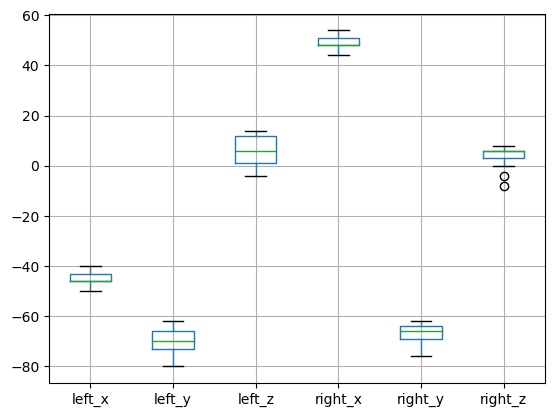

In [10]:
# summary of roi_ss_coords
print(roi_ss_coords.describe().round(2))

# boxplot roi_ss_coords
roi_ss_coords.boxplot(column=['left_x','left_y','left_z','right_x','right_y','right_z'])

In [11]:
# extract x,y,z coordinates of this subject's hMT+ roi
cluster_coords = [[0, 0, 0], [0, 0, 0]]
cluster_coords[0] = roi_ss_coords[roi_ss_coords['subject']==subject_label].iloc[:,0:3].values[0].tolist()
cluster_coords[1] = roi_ss_coords[roi_ss_coords['subject']==subject_label].iloc[:,3:6].values[0].tolist()

cluster_coords


[[-50, -70, 14], [52, -68, 8]]

In [12]:
labels = ['hMT+ L', 'hMT+ R']

masker_ss = NiftiSpheresMasker(
    cluster_coords,
    radius=8,
    detrend=True,
    standardize=False,
    high_pass=0.003,
    t_r=tr
    )

time_series = masker_ss.fit_transform(
    fmri_img, confounds=confounds
)

/opt/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/joblib/memory.py:349: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  return self.func(*args, **kwargs)


In [13]:
time_series.shape

(780, 2)

In [14]:
# create time vector based on the number of time points and the tr
time_vector = np.arange(0, time_series.shape[0]*tr, tr)
time_vector.shape

(780,)

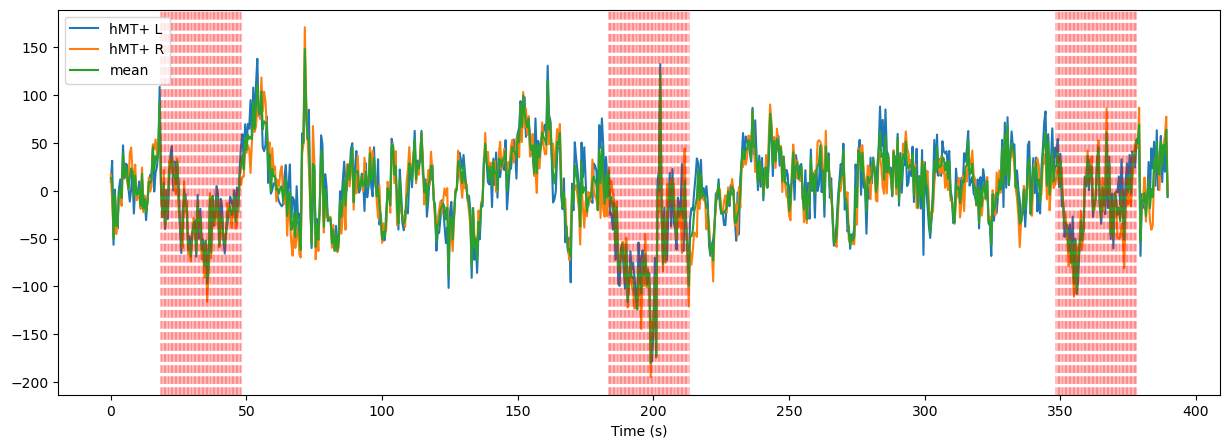

In [15]:
time_series_mean = time_series.mean(axis=1)

# plot the time series
plt.figure(figsize=(15, 5))
plt.plot(time_vector, time_series)
plt.plot(time_vector, time_series_mean)
plt.legend([labels[0],labels[1],'mean'])
plt.xlabel('Time (s)')

# highlight the time points of the static events
for i in range(len(static_events_indexes)):
    plt.axvline(x=time_vector[static_events_indexes[i]], color='r', linestyle='--', alpha=0.25)

plt.show()

In [16]:
# calculate percent signal change to static events
time_series_mean_static = time_series_mean[static_events_indexes]
time_series_mean_static.mean()

time_series_mean_psc = (time_series_mean - time_series_mean_static.mean()) / abs(time_series_mean_static.mean())

# plot the time series
plt.figure(figsize=(15, 5))
plt.plot(time_vector,time_series_mean_psc)
plt.legend(['mean'])
plt.xlabel('Time (s)')
# highlight the time points of the static events
for i in range(len(static_events_indexes)):
    plt.axvline(x=time_vector[static_events_indexes[i]], color='r', linestyle='--', alpha=0.25)


In [17]:
# estimate event related response
time_series_mean_psc_active = time_series_mean_psc[active_events_indexes]
time_series_mean_psc_active_length = time_series_mean_psc_active.shape[0]//2

# reshape to two columns with half the points each
time_series_mean_psc_active = time_series_mean_psc_active.reshape((2,time_series_mean_psc_active_length)).T

# estimate mean and std
time_series_mean_psc_active_mean = time_series_mean_psc_active.mean(axis=1)
time_series_mean_psc_active_std = time_series_mean_psc_active.std(axis=1)

# create time vector based on the number of time points and the tr
time_vector_active = np.arange(0, time_series_mean_psc_active_length*tr, tr)

# plot the time series
plt.figure(figsize=(15, 5))
plt.plot(time_vector_active, time_series_mean_psc_active_mean)
plt.fill_between(time_vector_active, time_series_mean_psc_active_mean-time_series_mean_psc_active_std, time_series_mean_psc_active_mean+time_series_mean_psc_active_std, alpha=0.25)
plt.legend(['bilateral hMT+'])
plt.hlines(0, 0, time_vector_active[-1], color='k', linestyle='--', alpha=0.25)
plt.ylabel('Percent signal change to static')
plt.xlabel('Time (s)')


Text(0.5, 0, 'Time (s)')

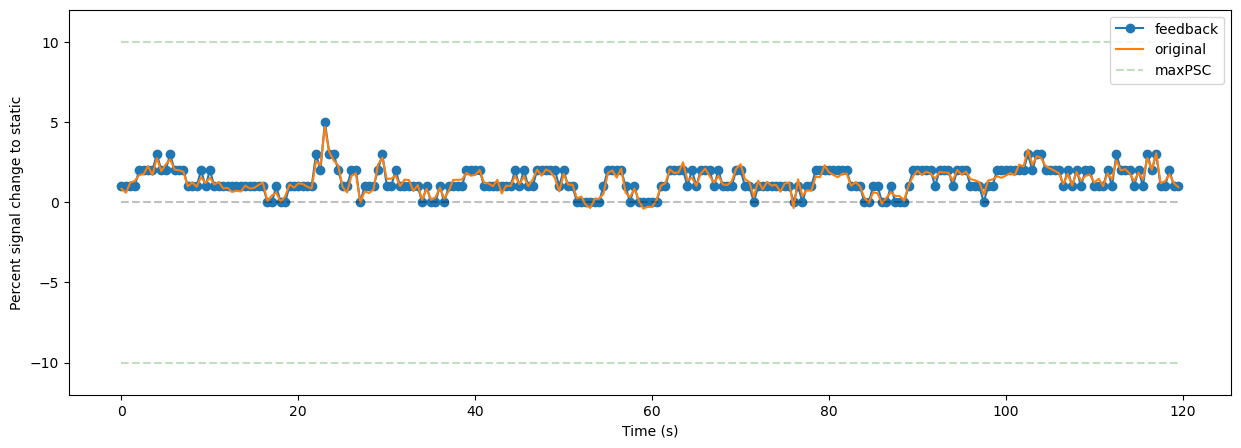

In [21]:
# feedback signal simulation
# remap time_series_mean_psc_active to a scale between 0 and 10 with step 1. 0 corresponds to psc 0 and 10 corresponds to psc 5. the max value must be 5.
max_psc = 10
time_series_mean_psc_active_mean_remap = np.round((time_series_mean_psc_active_mean) * 10 / max_psc)

time_series_mean_psc_active_mean_remap[time_series_mean_psc_active_mean_remap>max_psc] = max_psc

# plot them both together
plt.figure(figsize=(15, 5))
plt.plot(time_vector_active,time_series_mean_psc_active_mean_remap, linestyle='solid', marker='o')
plt.plot(time_vector_active,time_series_mean_psc_active_mean)
plt.hlines(max_psc, 0, time_vector_active[-1], color='g', linestyle='--', alpha=0.25)
plt.legend(['feedback', 'original', 'maxPSC'])
plt.hlines(-max_psc, 0, time_vector_active[-1], color='g', linestyle='--', alpha=0.25)
plt.hlines(0, 0, time_vector_active[-1], color='k', linestyle='--', alpha=0.25)
plt.ylabel('Percent signal change to static')
plt.xlabel('Time (s)')
plt.ylim((-max_psc-2, max_psc+2))
plt.show()